# [LAB-02] 06. 계층적 튜닝・평가

## #01. 준비작업

### 1. 라이브러리 참조

In [57]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, crosstab
from sklearn.metrics import silhouette_score

### 2. 데이터 가져오기

In [58]:
origin = load_data("iris")
origin.head()

📚 1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

    field         description
--  ------------  -------------
 0  Sepal.Length  꽃받침 길이
 1  Sepal.Width   꽃받침 너비
 2  Petal.Length  꽃잎 길이
 3  Petal.Width   꽃잎 너비
 4  Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


### 3. 종속변수 제거 + 데이터 스케일링

In [59]:
df = origin.drop("Species", axis=1)

sdf = my_prep.scaling(df, method="standard", verbose=False)
sdf.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,-0.901,1.019,-1.340,-1.315
1,-1.143,-0.132,-1.340,-1.315
2,-1.385,0.328,-1.397,-1.315
3,-1.507,0.098,-1.283,-1.315
4,-1.022,1.249,-1.340,-1.315


## #02. 최적의 군집수 찾기

### 1. 군집수를 바꿔 가며 실루엣 스코어 확인

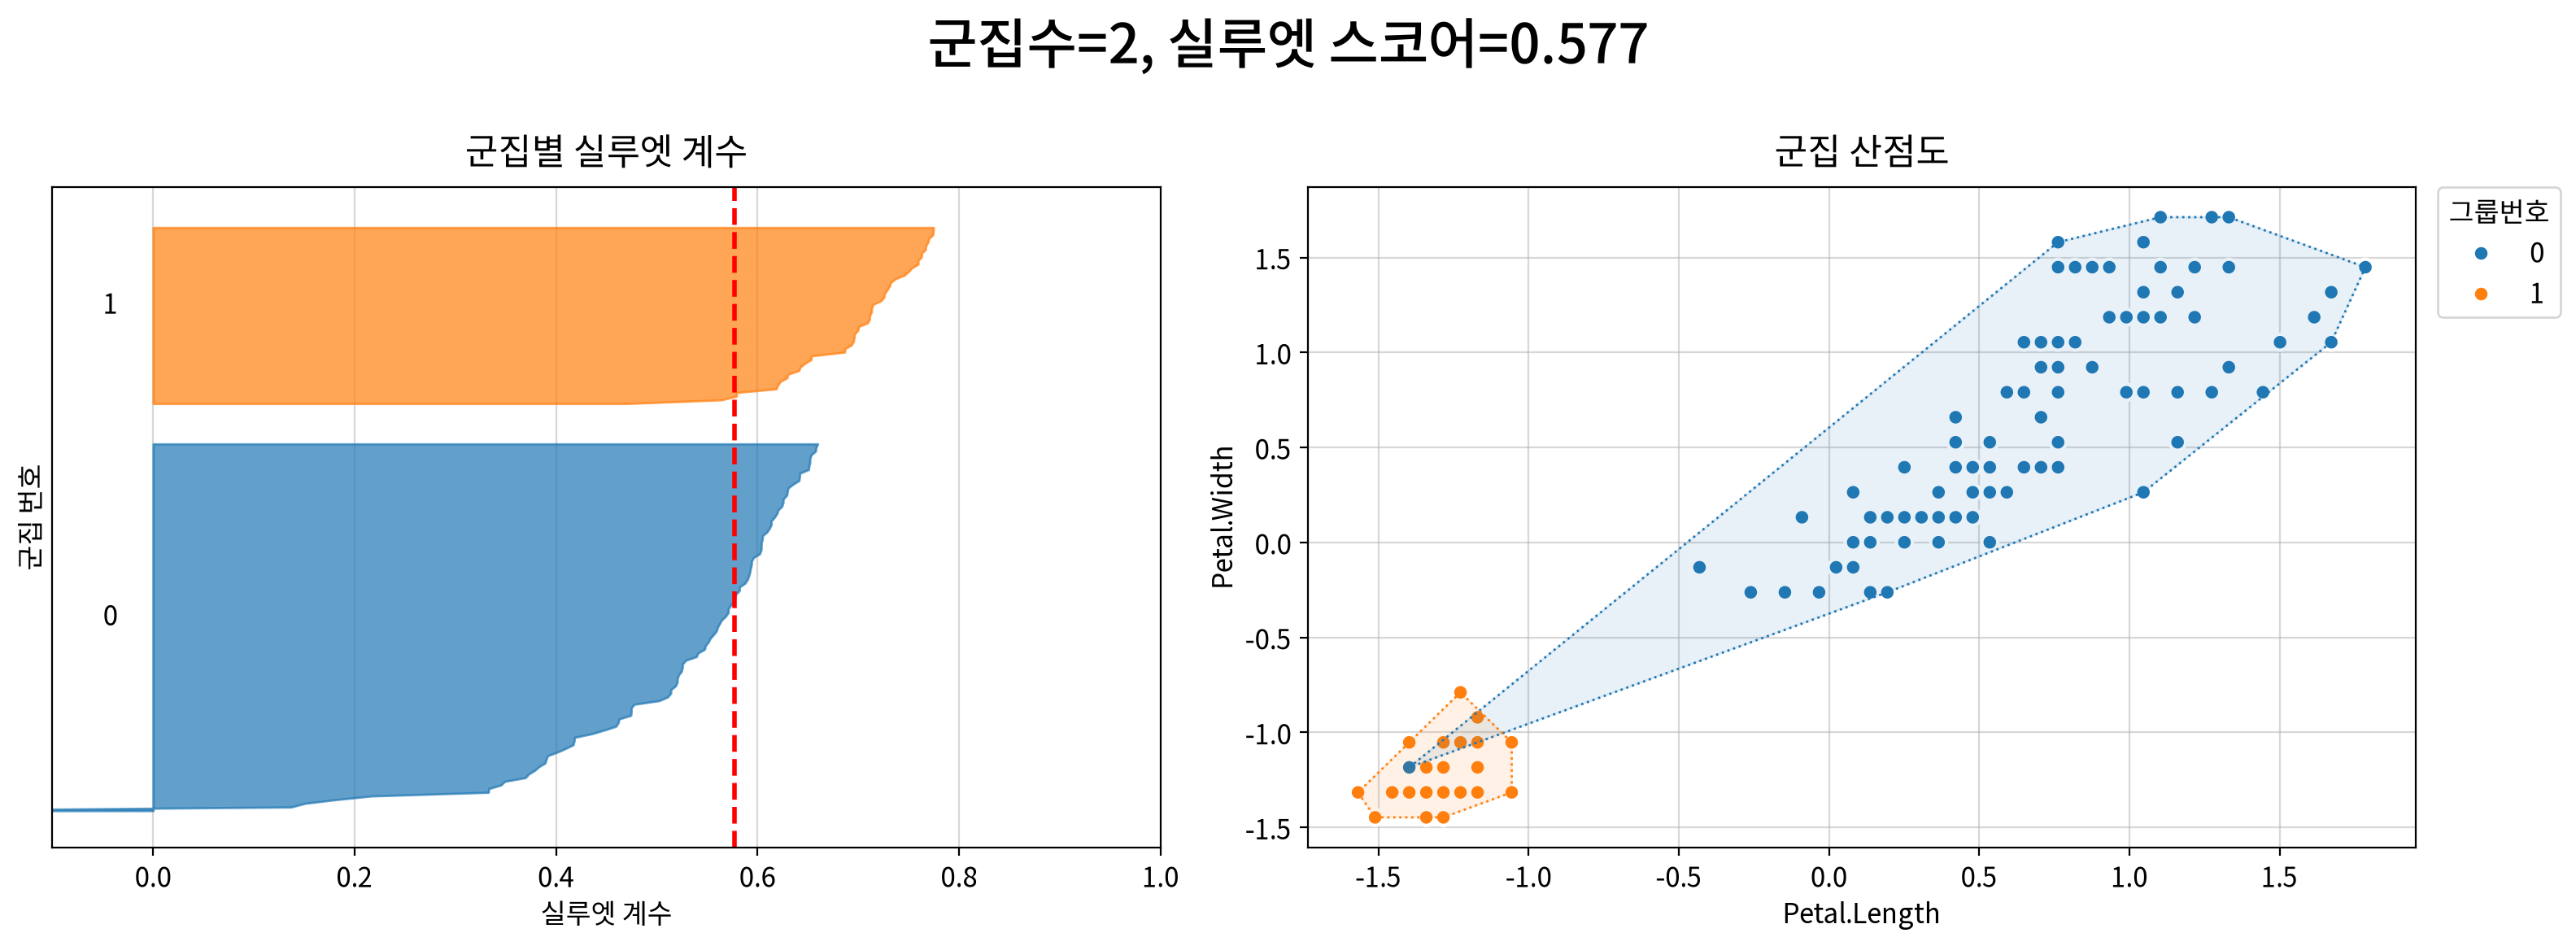

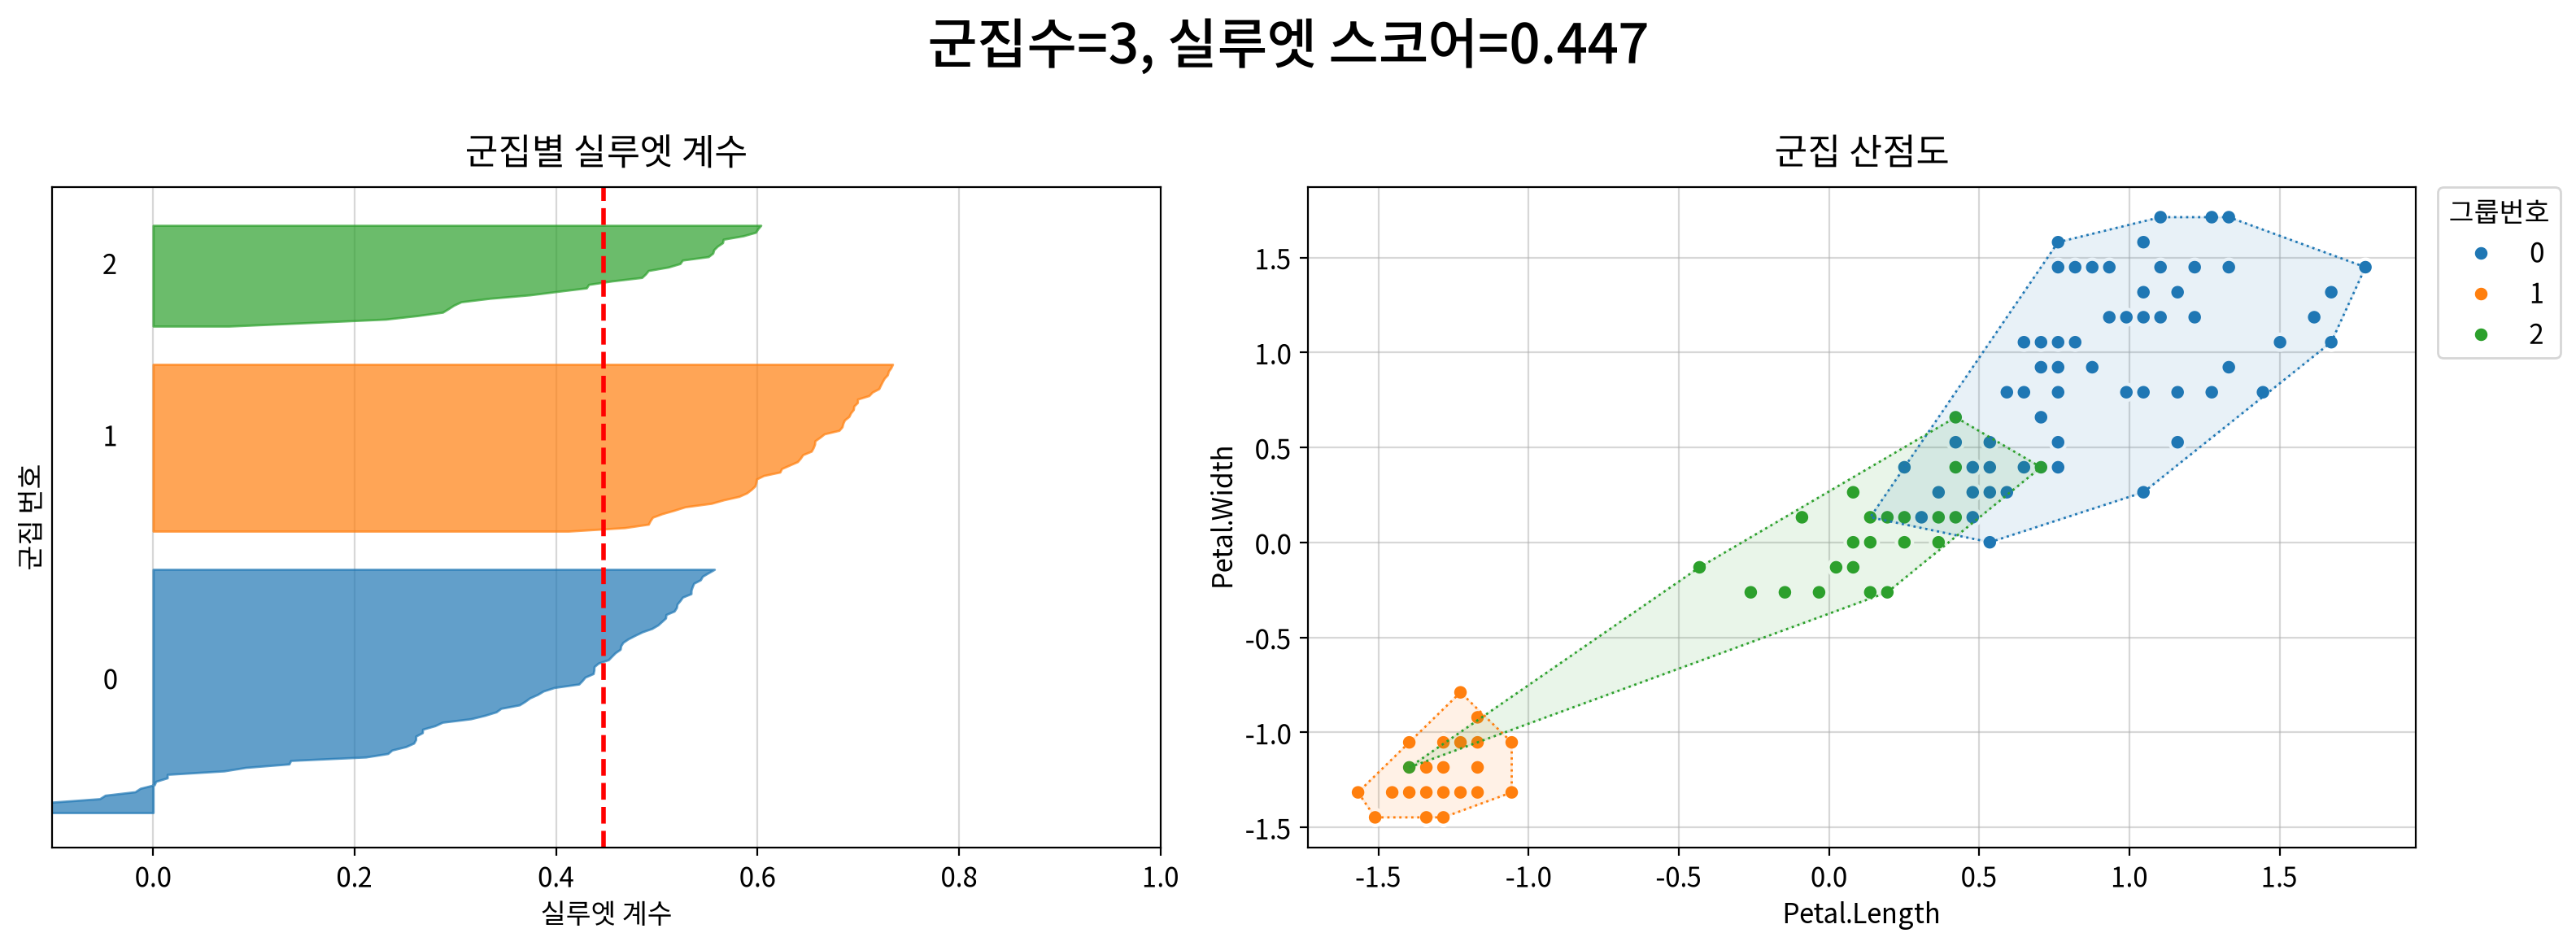

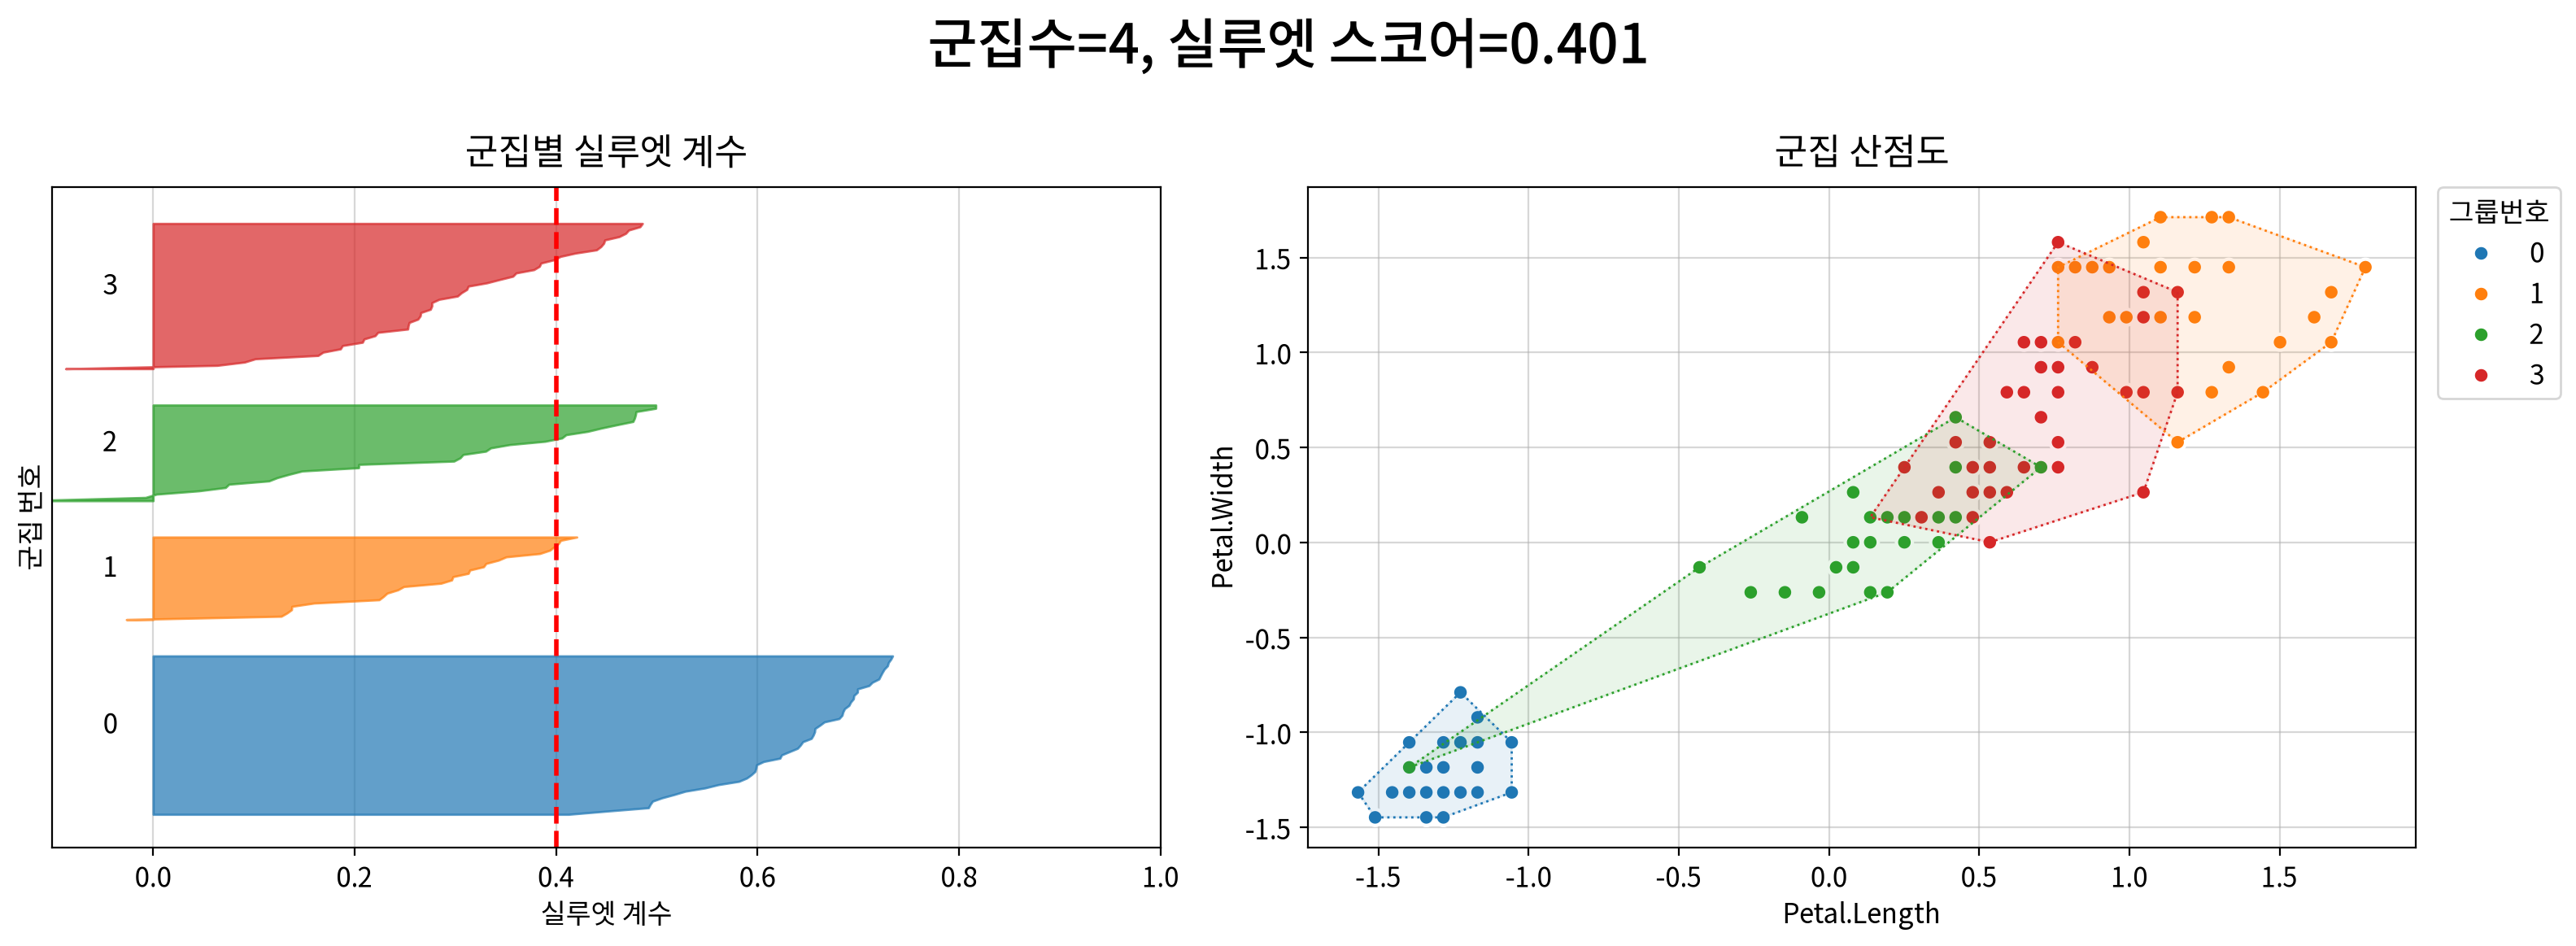

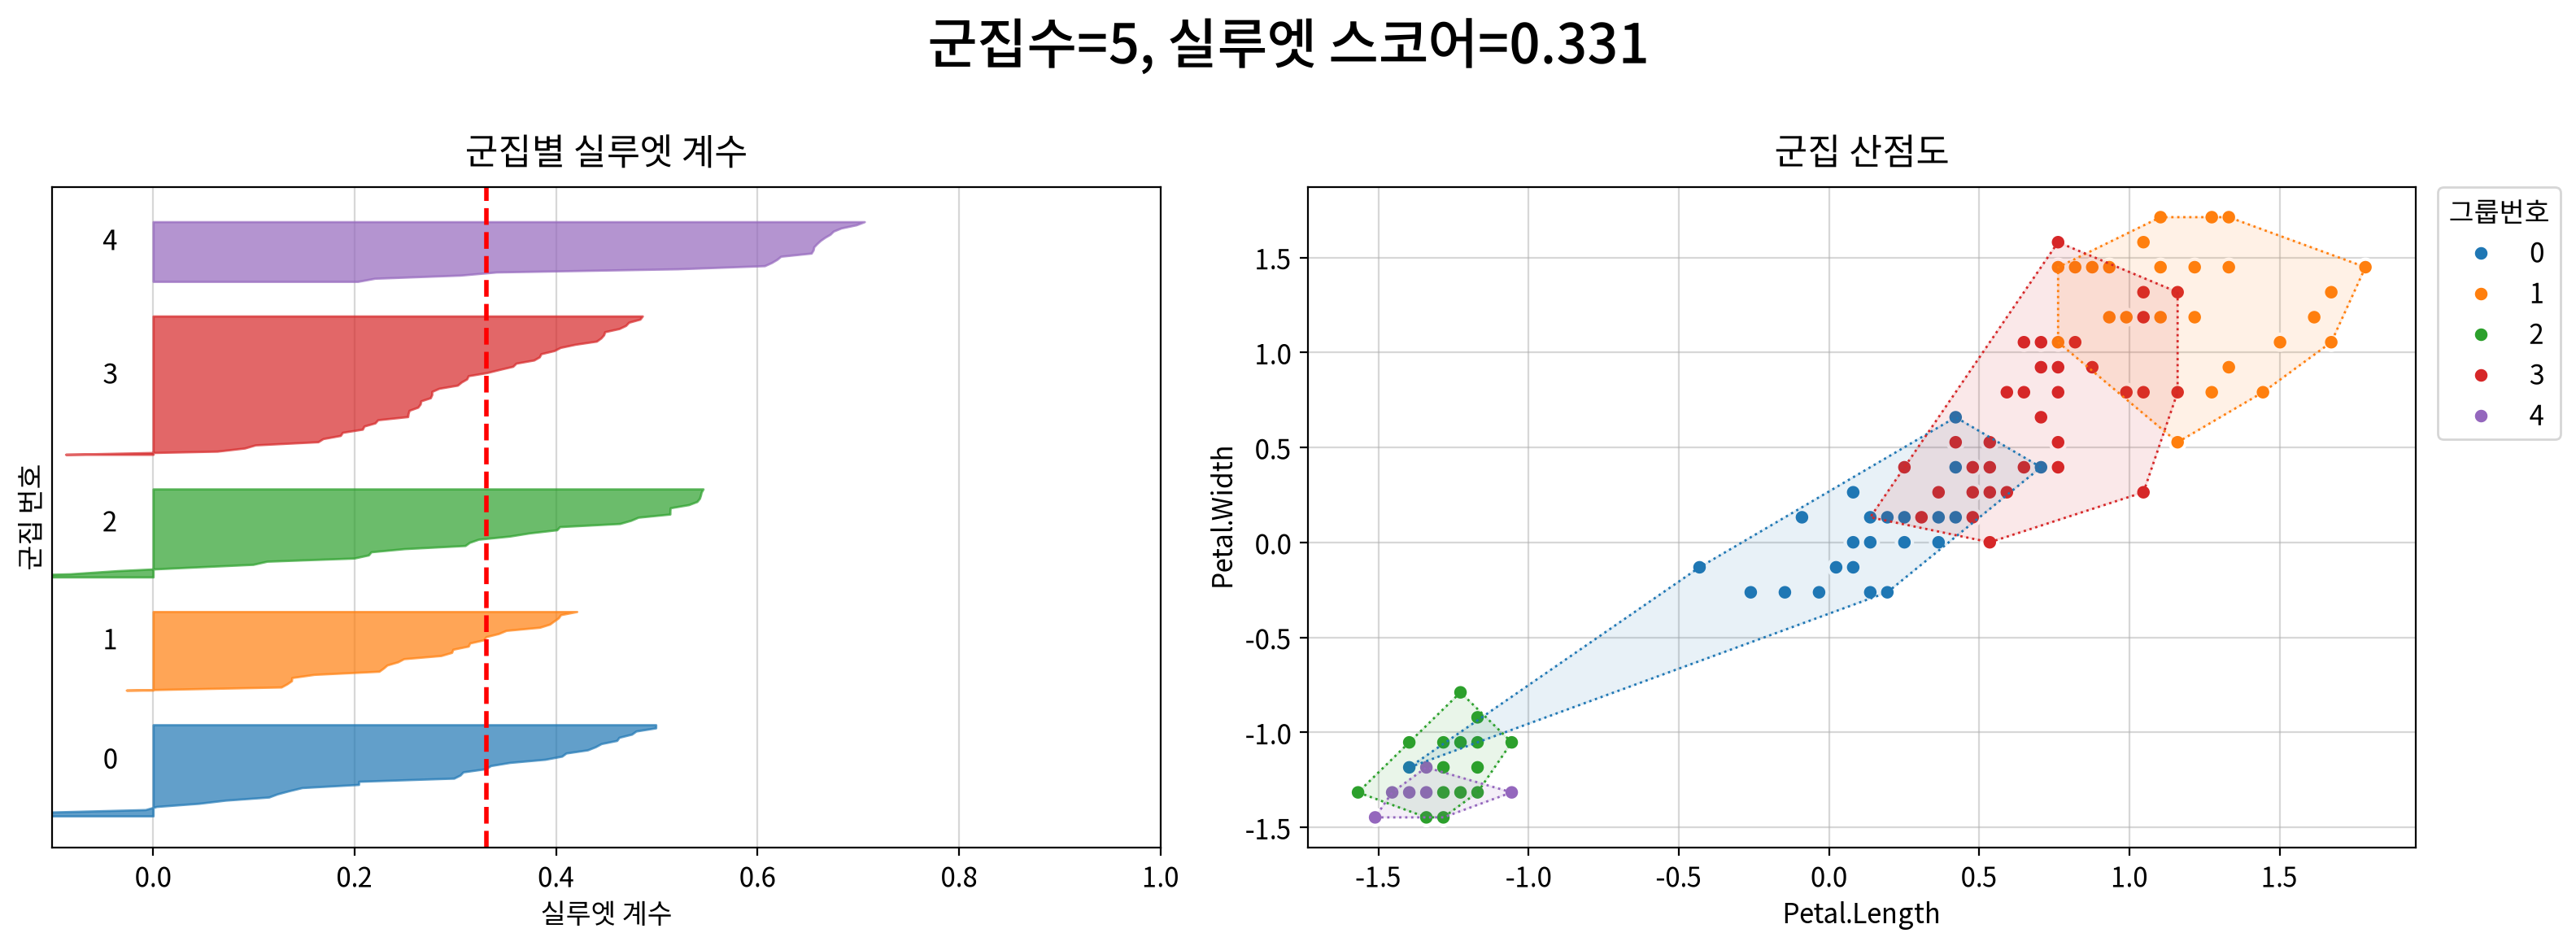

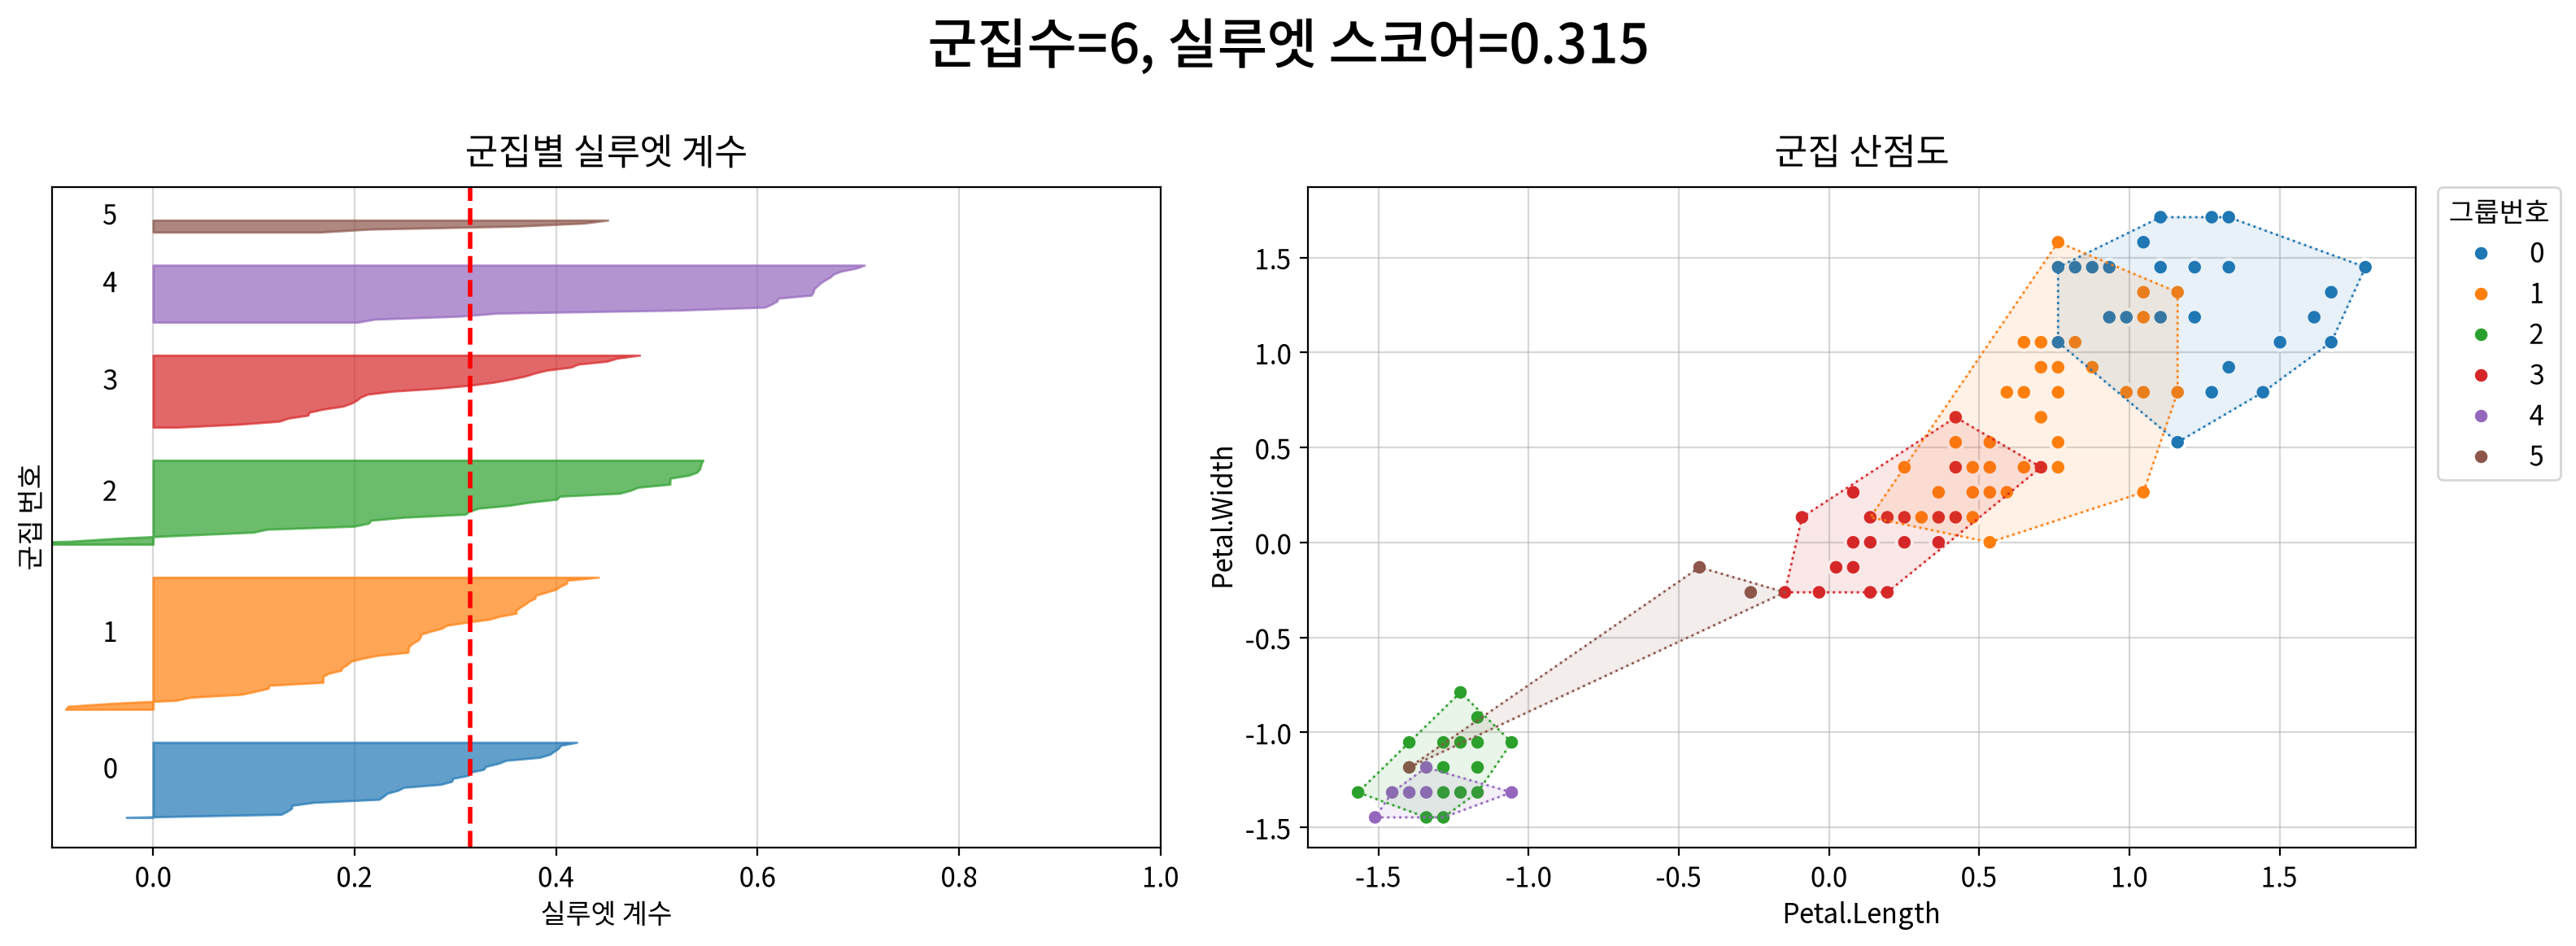

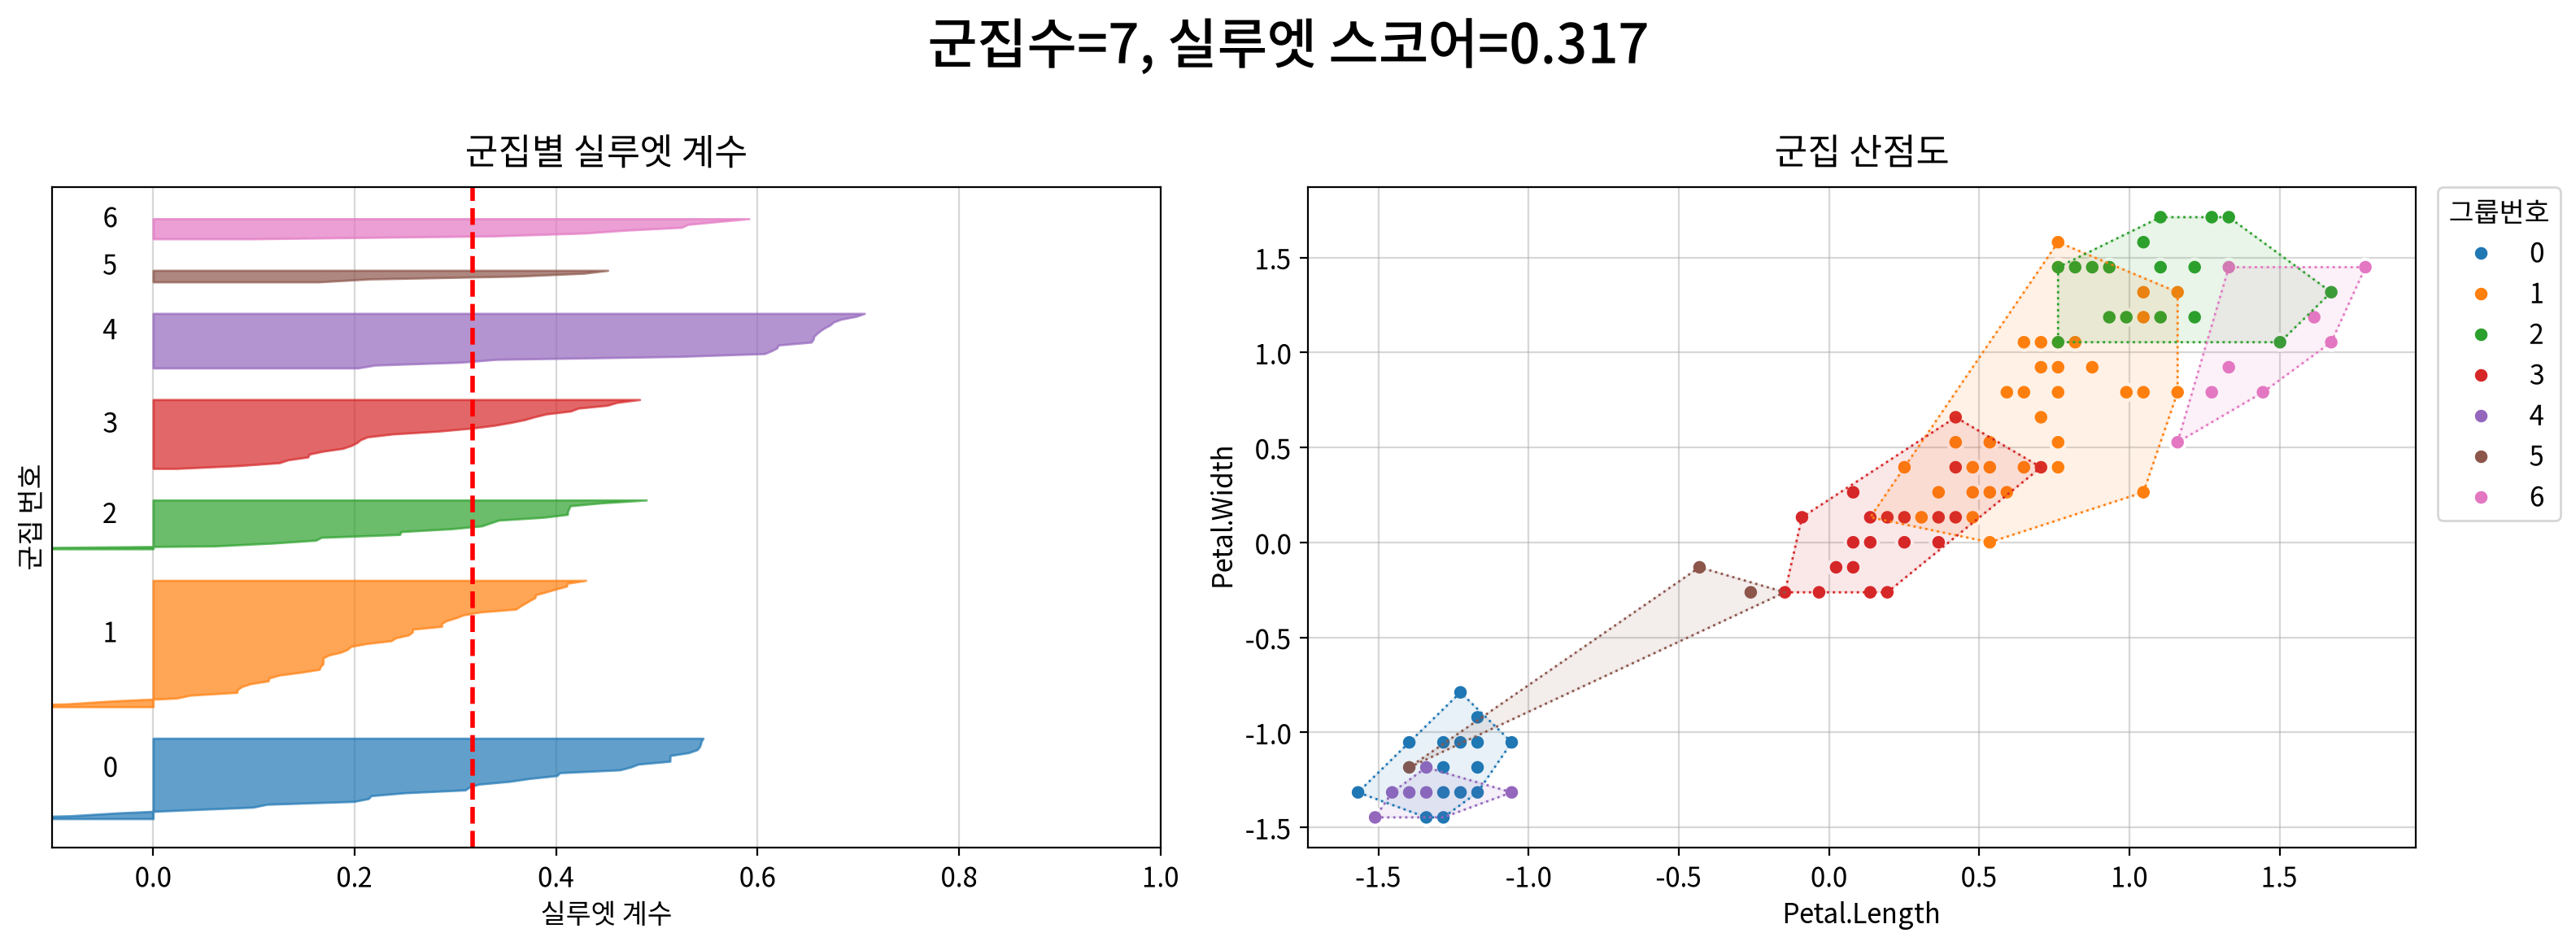

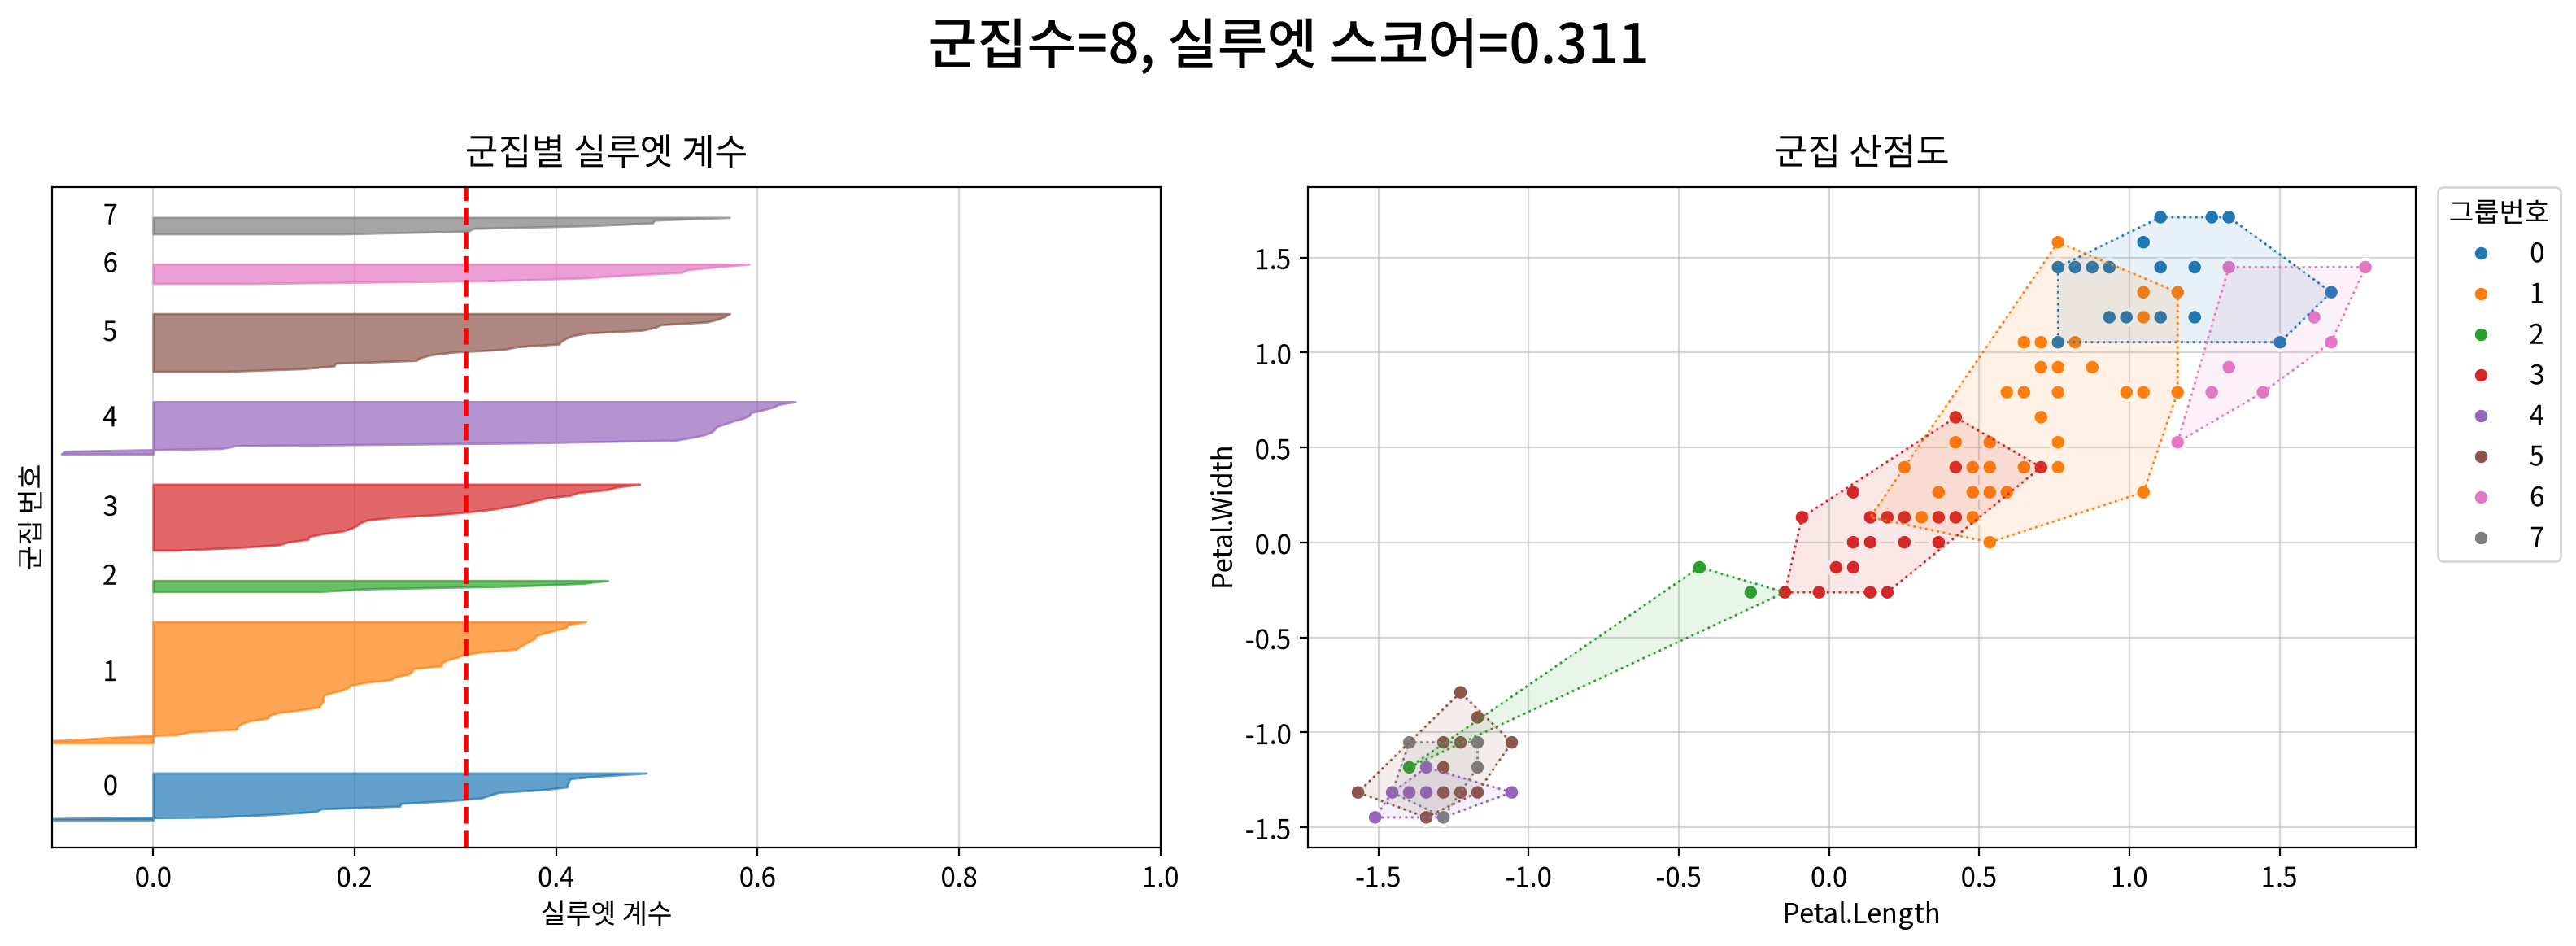

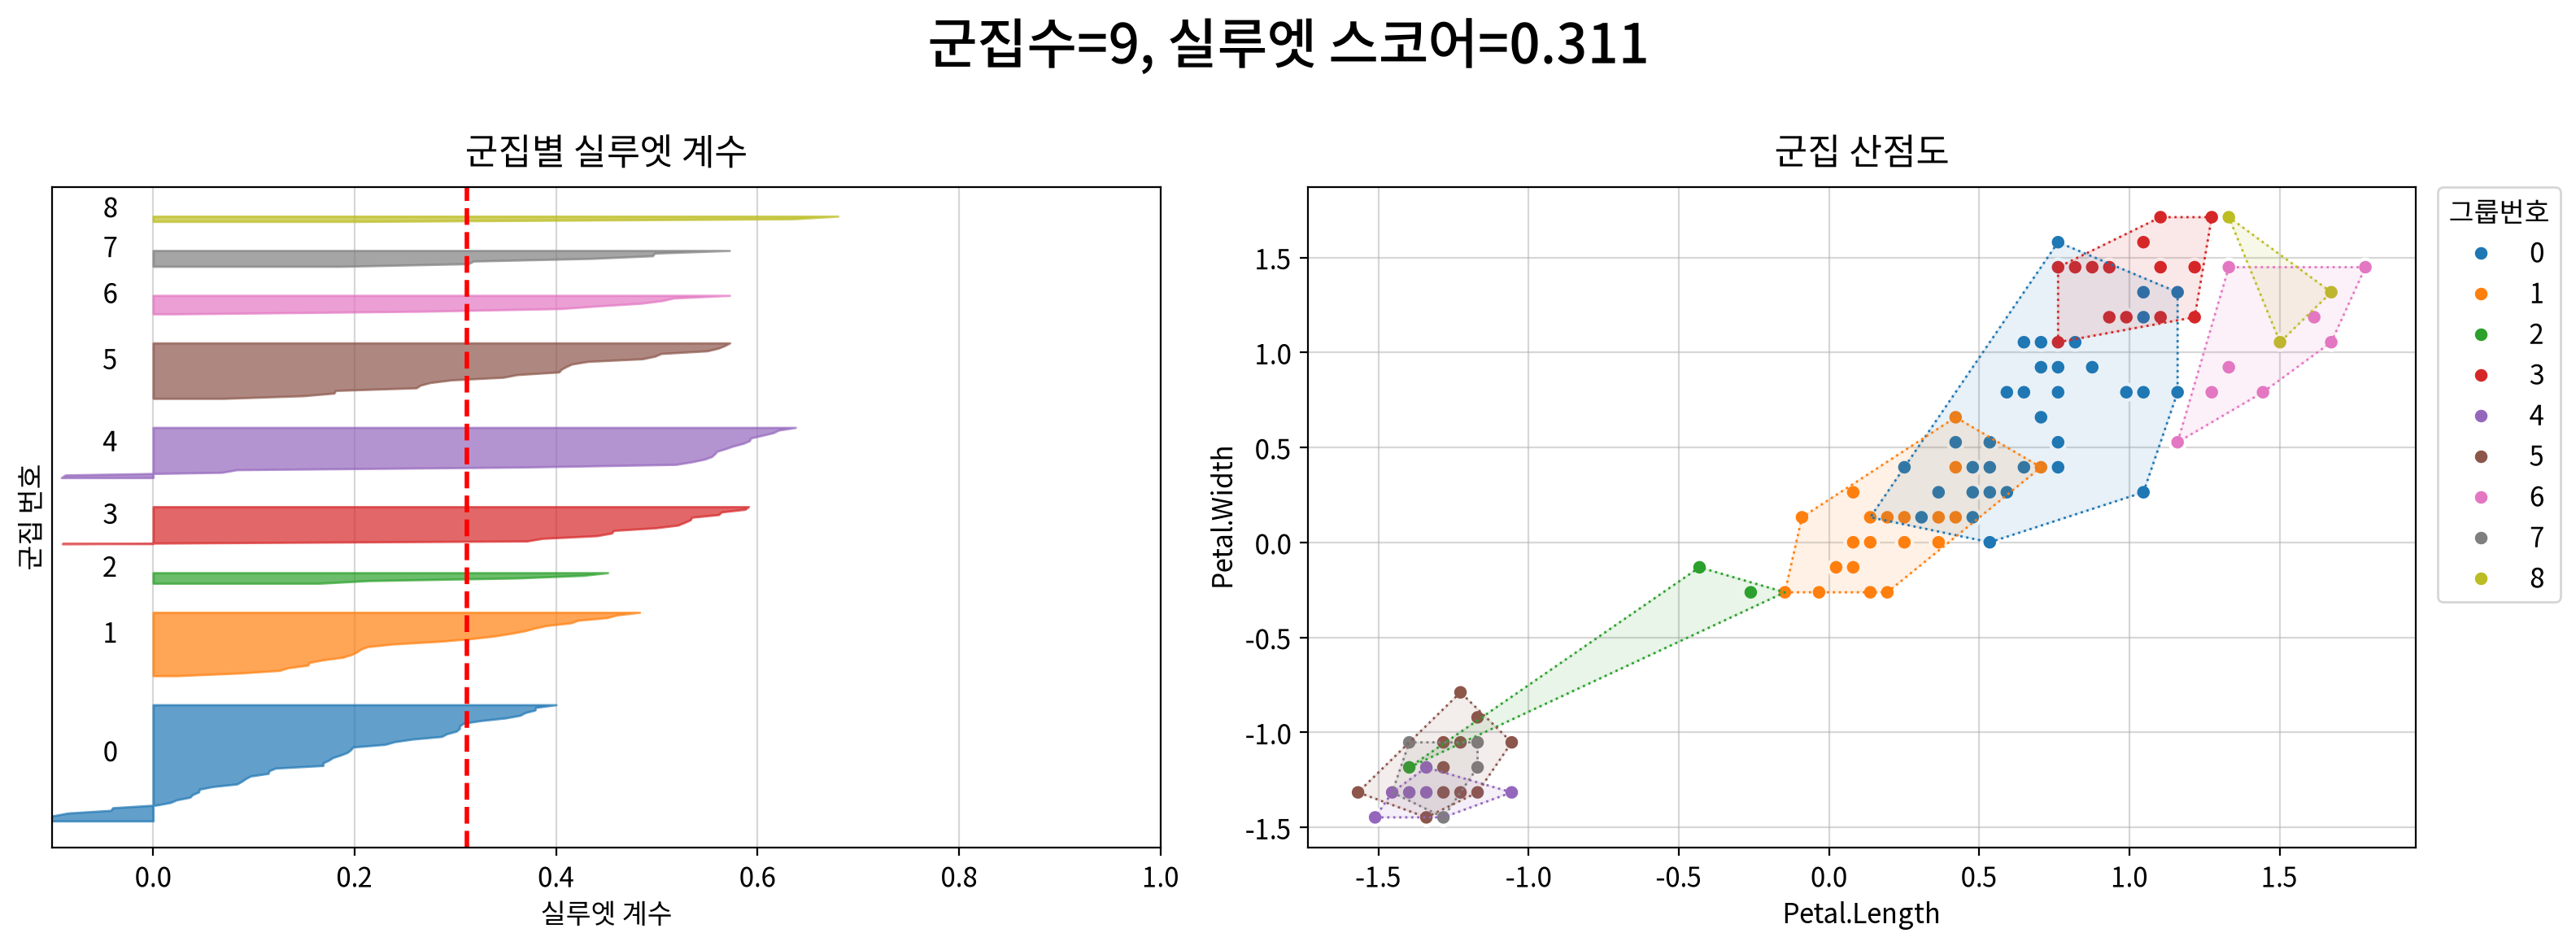

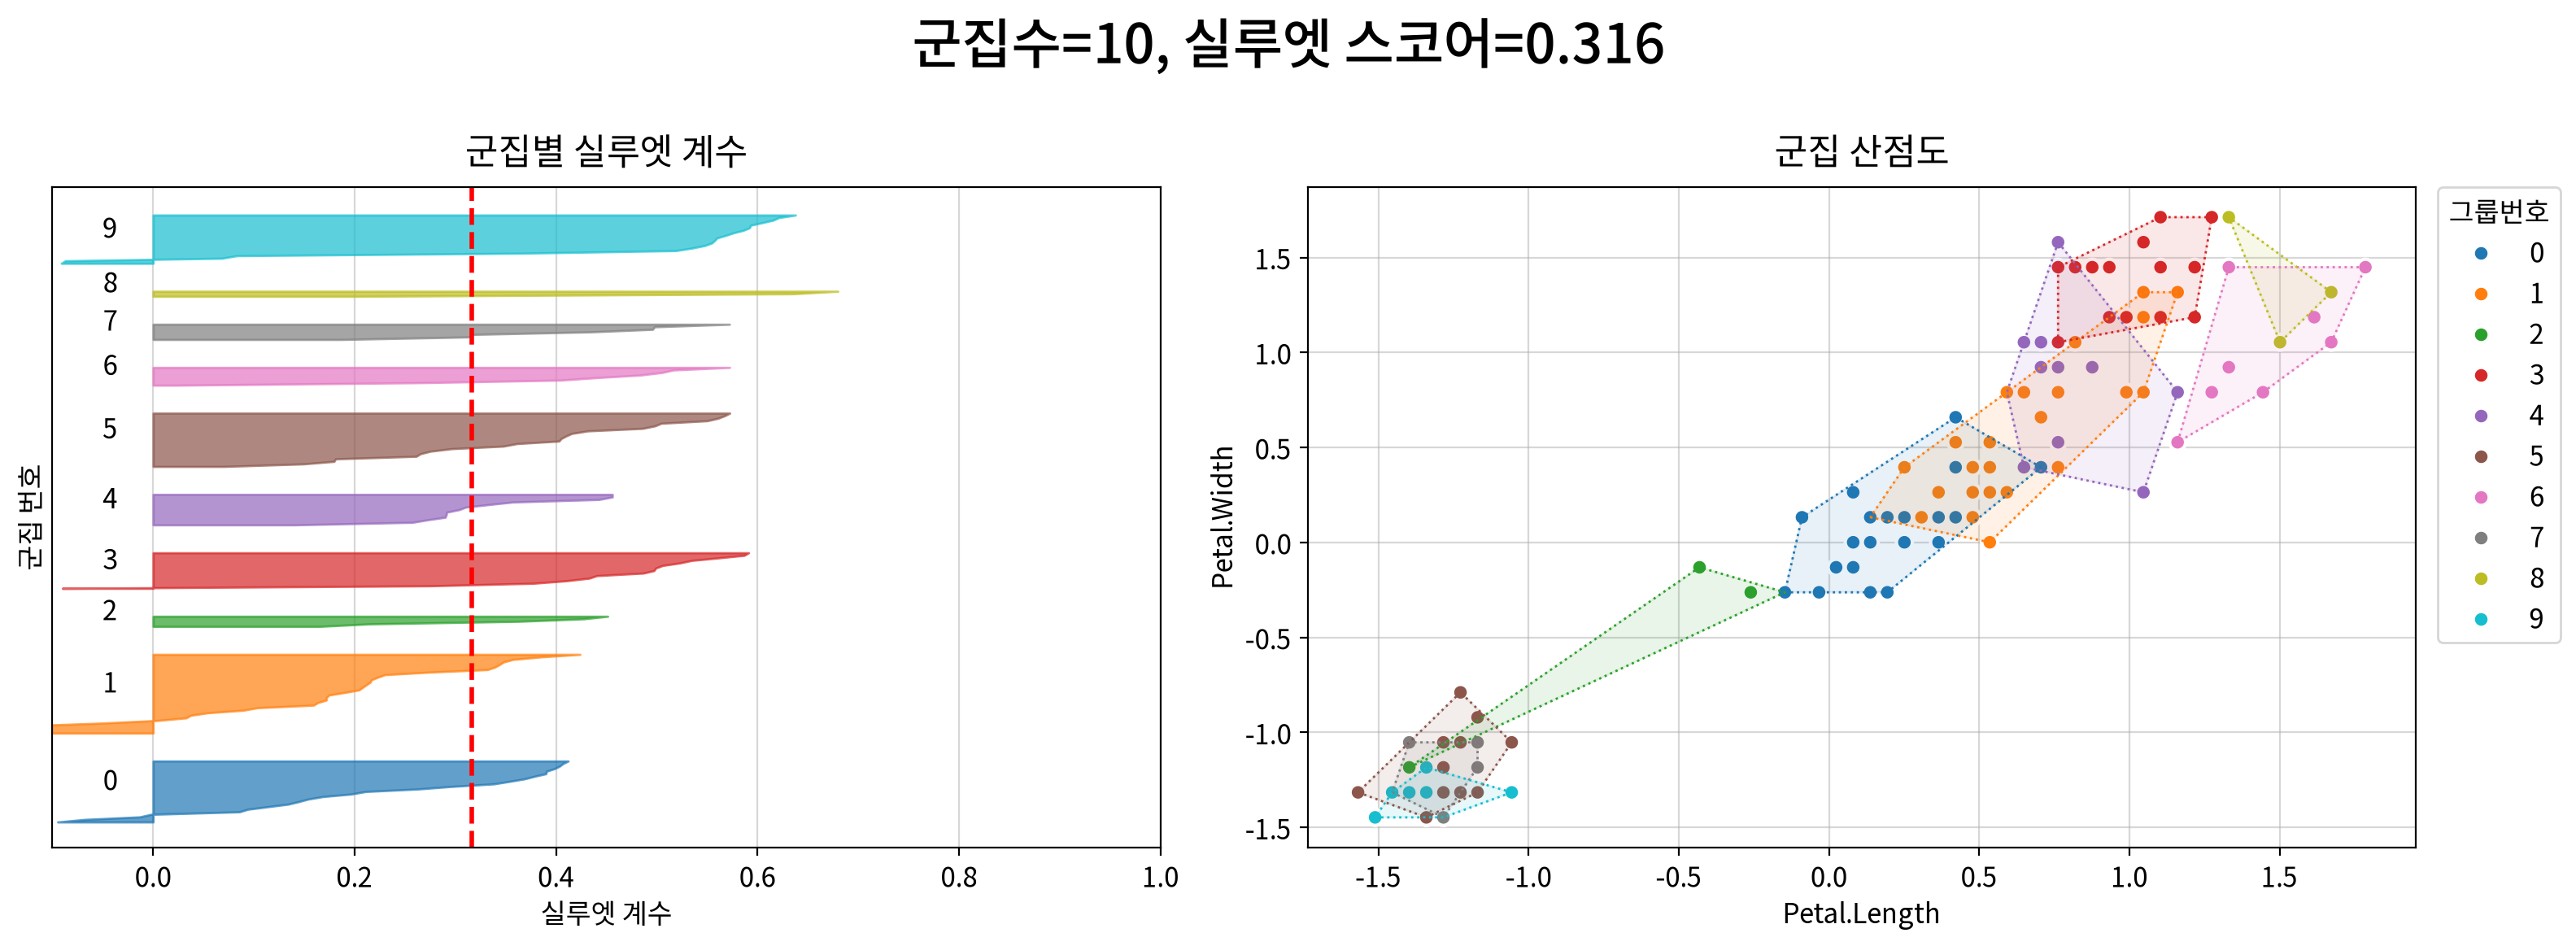

,k,score
0,2,0.577
1,3,0.447
2,4,0.401
3,5,0.331
5,7,0.317
8,10,0.316
4,6,0.315
7,9,0.311
6,8,0.311


In [60]:
klist = list(range(2, 11))  # 군집수를 2~10개로 지정
s_items = []                # 군집수별 실루엣 점수를 담을 리스트

for k in klist:             # 군집수별로 반복
    # 이미 스케일링을 처리했으므로 모듈 내부에서는 다시 수행하지 않도록 scaling=None 을 지정
    # (덴드로그램은 k가 바뀌어도 나무 모양이 같으므로 여기서는 그리지 않는다)
    estimator, cdf = my_cluster.agglomerative(sdf, k=k, scaling=None, 
                                              verbose=False, plot=False)

    # 실루엣 막대 + 군집 산점도를 한 번에 그려주는 helpers 함수
    # (반환된 데이터에 들어 있는 군집번호 컬럼은 함수가 알아서 제외한다)
    my_cluster.visualize_silhouette(estimator, cdf, x="Petal.Length", y="Petal.Width")

    # 추정기(estimator)에서 군집번호를 가져와 실루엣 점수를 계산
    sh_score = round(silhouette_score(X=sdf, labels=estimator.labels_), 4)
    s_items.append({"k": k, "score": sh_score})

score_df = DataFrame(s_items).sort_values(by="score", ascending=False)
score_df

#### 💡 인사이트

| K | 실루엣 스코어 |
|---|---|
| 2 | 가장 높음 |
| **3** | 두 번째 |
| 4 이상 | 계속 떨어짐 |

점수만 보면 K = 2 지만, 4단원에서와 같은 이유로 **K = 3** 을 택한다.

- 붓꽃은 **3종**으로 알려져 있다 (도메인 지식)
- K = 3 의 점수도 K = 4 보다 높다 (지표상으로도 무리가 없다)
- 3개 그룹이 "작은 꽃 / 중간 꽃 / 큰 꽃"으로 **설명된다**

> **지표는 후보를 좁혀 주고, 마지막 결정은 목적이 한다.**

## #03. 최종 모형 적합

### 1. 최적 군집수 적용 모델

In [61]:
best_k = 3

[계층적 군집] 군집 수 = 3, 연결 방법 = ward, 거리 = euclidean
  · 자른 높이(병합 거리) = 10.3208
  · 군집별 데이터 개수 : 0번 71개, 1번 49개, 2번 30개


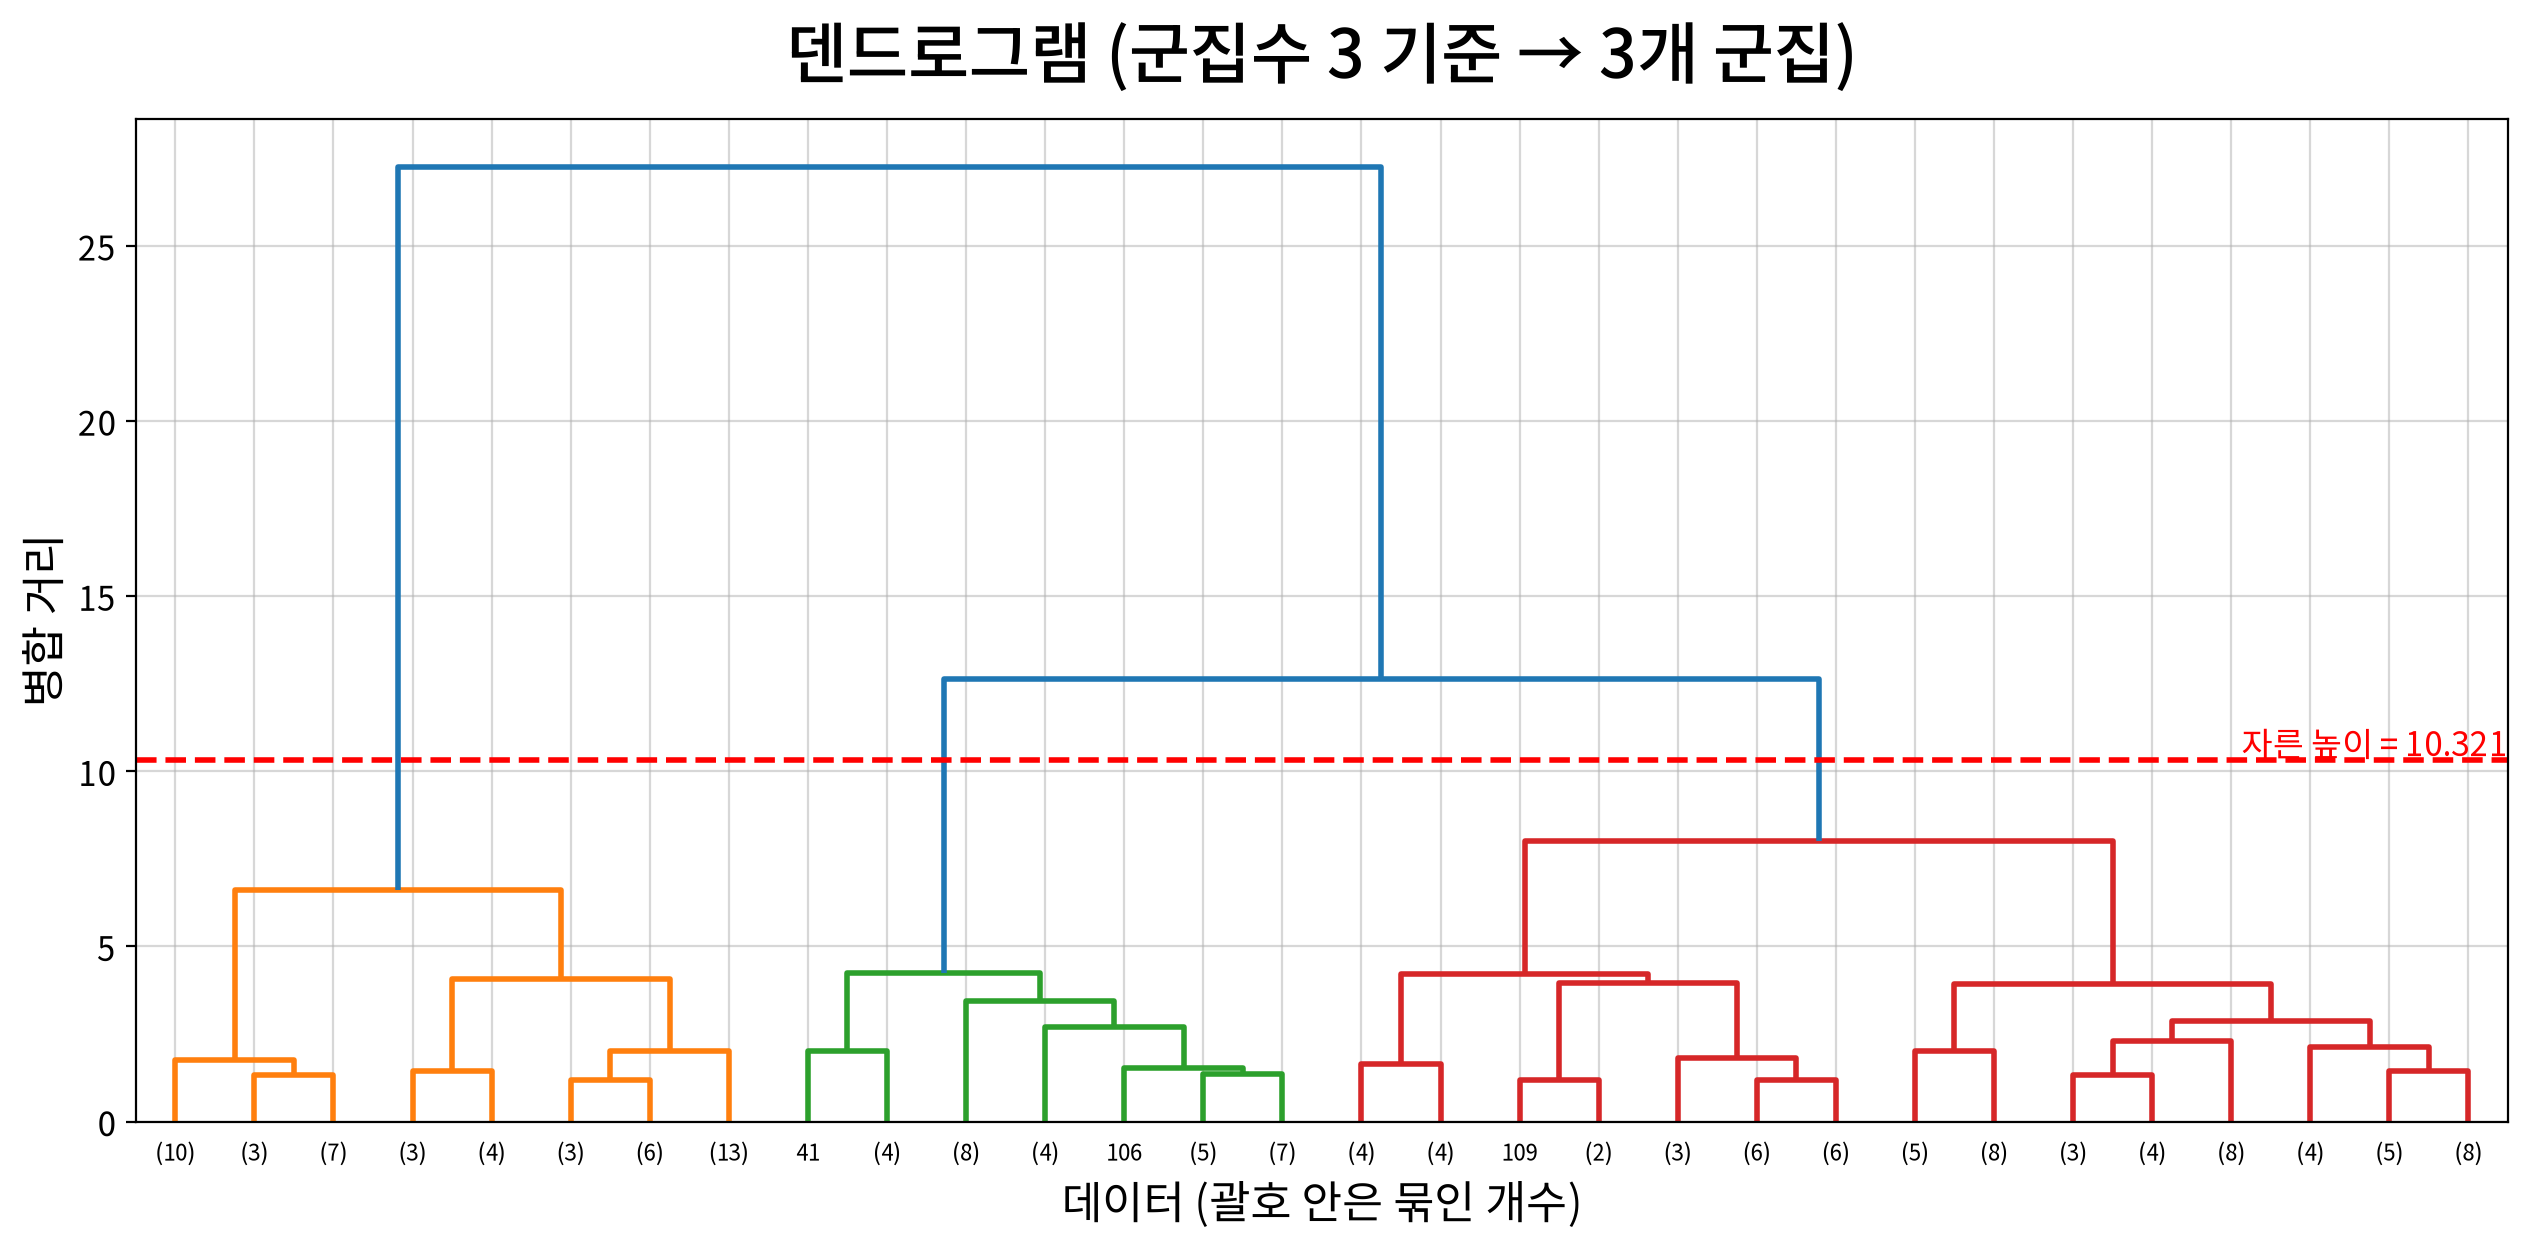

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,그룹번호
0,5.100,3.500,1.400,0.200,1
1,4.900,3.000,1.400,0.200,1
2,4.700,3.200,1.300,0.200,1
3,4.600,3.100,1.500,0.200,1
4,5.000,3.600,1.400,0.200,1


In [63]:
# 이미 스케일링을 마쳤으므로 scaling=None
estimator, cdf = my_cluster.agglomerative(sdf, k=best_k,  scaling=None)

# 해석은 원본 단위(cm)로 해야 하므로 원본 데이터에 군집 번호만 옮겨 붙인다
result_df = df.copy()
result_df["그룹번호"] = cdf["그룹번호"]
result_df.head()

#### 💡인사이트

- **덴드로그램 해석**
  - 맨 위 - 두 개의 큰 덩어리
    - 마지막에 두 덩어리가 합쳐진다
    - 데이터가 크게 둘로 나뉜다는 의미
    - 실루엣이 K = 2 를 가장 높게 준 이유가 바로 이것이다.
  - 중간 높이 - 다시 둘로 갈라짐
    - 오른쪽 덩어리가 중간 높이에서 다시 둘로 갈라진다.
    - 여기까지 보면 3개 그룹이다.
  - 아래쪽 - 촘촘한 병합
    - 짧은 거리에서 촘촘히 합쳐진다
    - 더 잘게 나눌 이유가 없다.
    
> 덴드로그램은 "몇 개로 나눌까"를 눈으로 결정하게 해준다

### 2. 군집 결과 시각화

꽃받침(Sepal)과 꽃잎(Petal) 두 가지로 나누어 그려 본다.

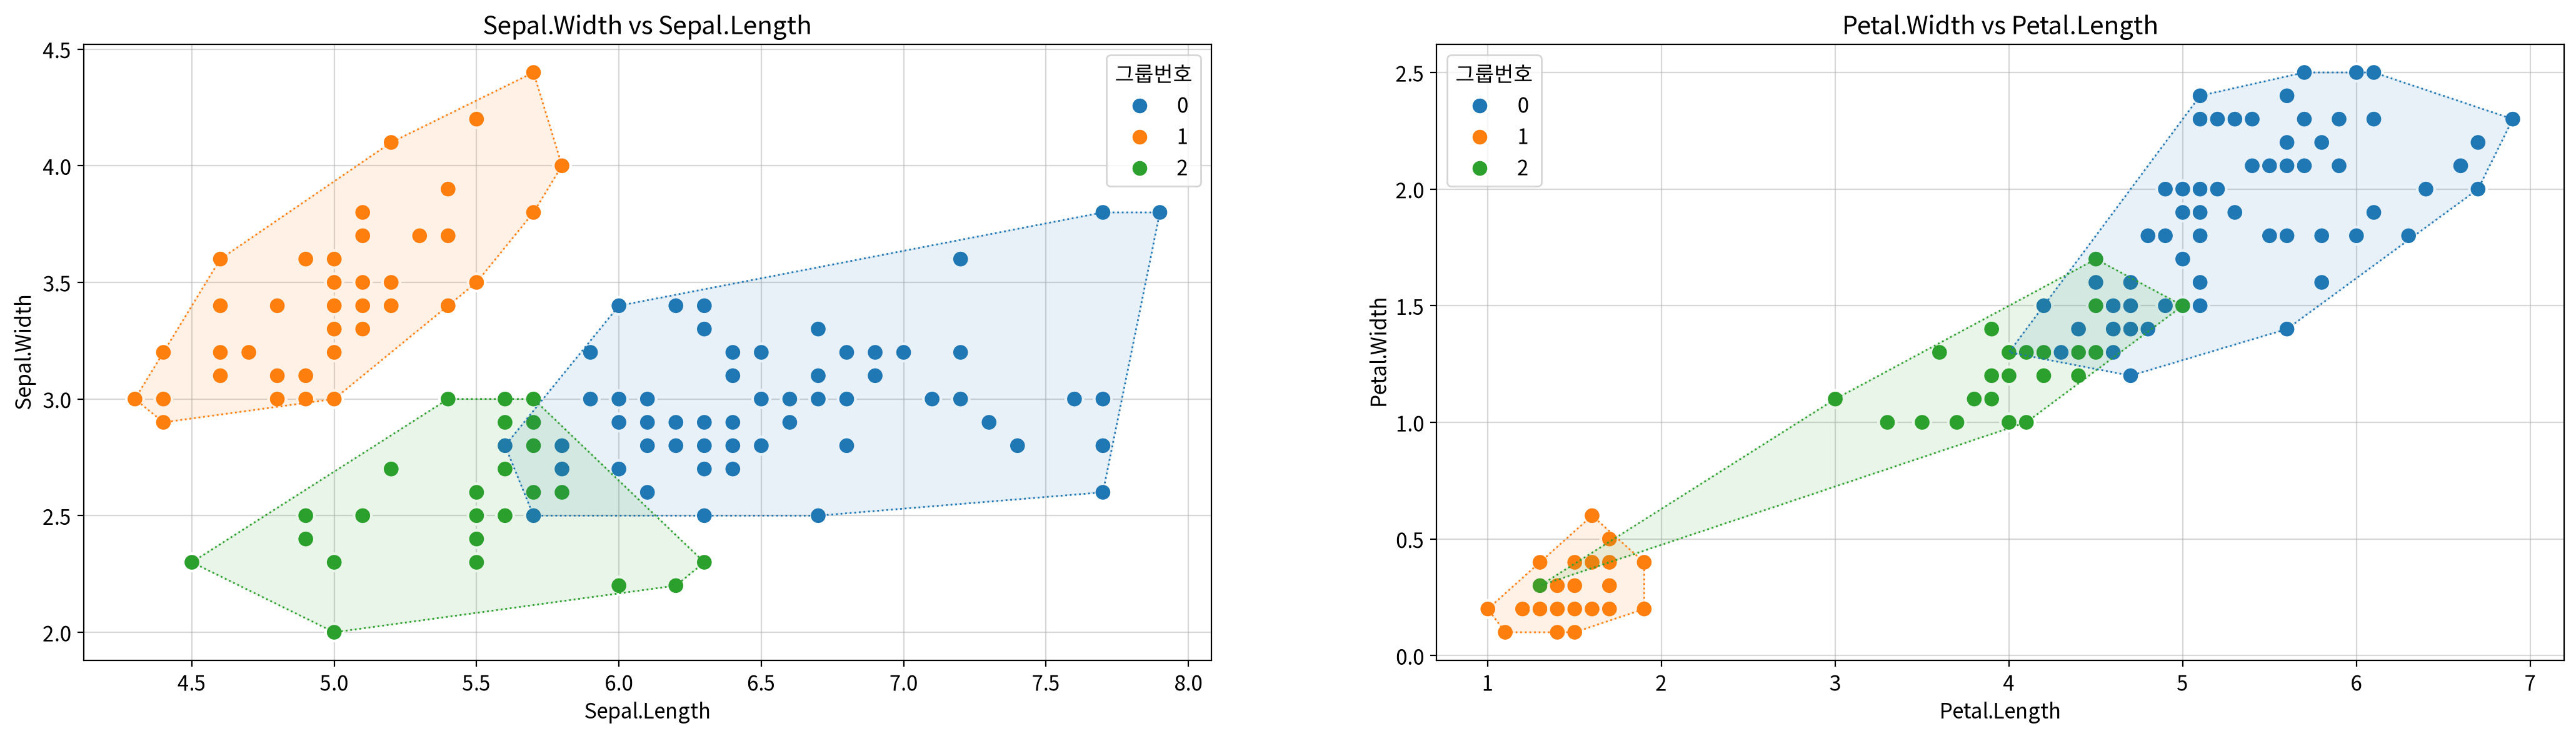

In [64]:
vs_fields = [["Sepal.Length", "Sepal.Width"], ["Petal.Length", "Petal.Width"]]

fig, ax = my_plot.init(rows=1, cols=2)

for i, (x_field, y_field) in enumerate(vs_fields):
    my_plot.scatterplot(data=result_df, x=x_field, y=y_field, hue="그룹번호",
                        outline=True, ax=ax[i])

    ax[i].set_title(f"{y_field} vs {x_field}")

### 3. 최종 모형의 실루엣 확인

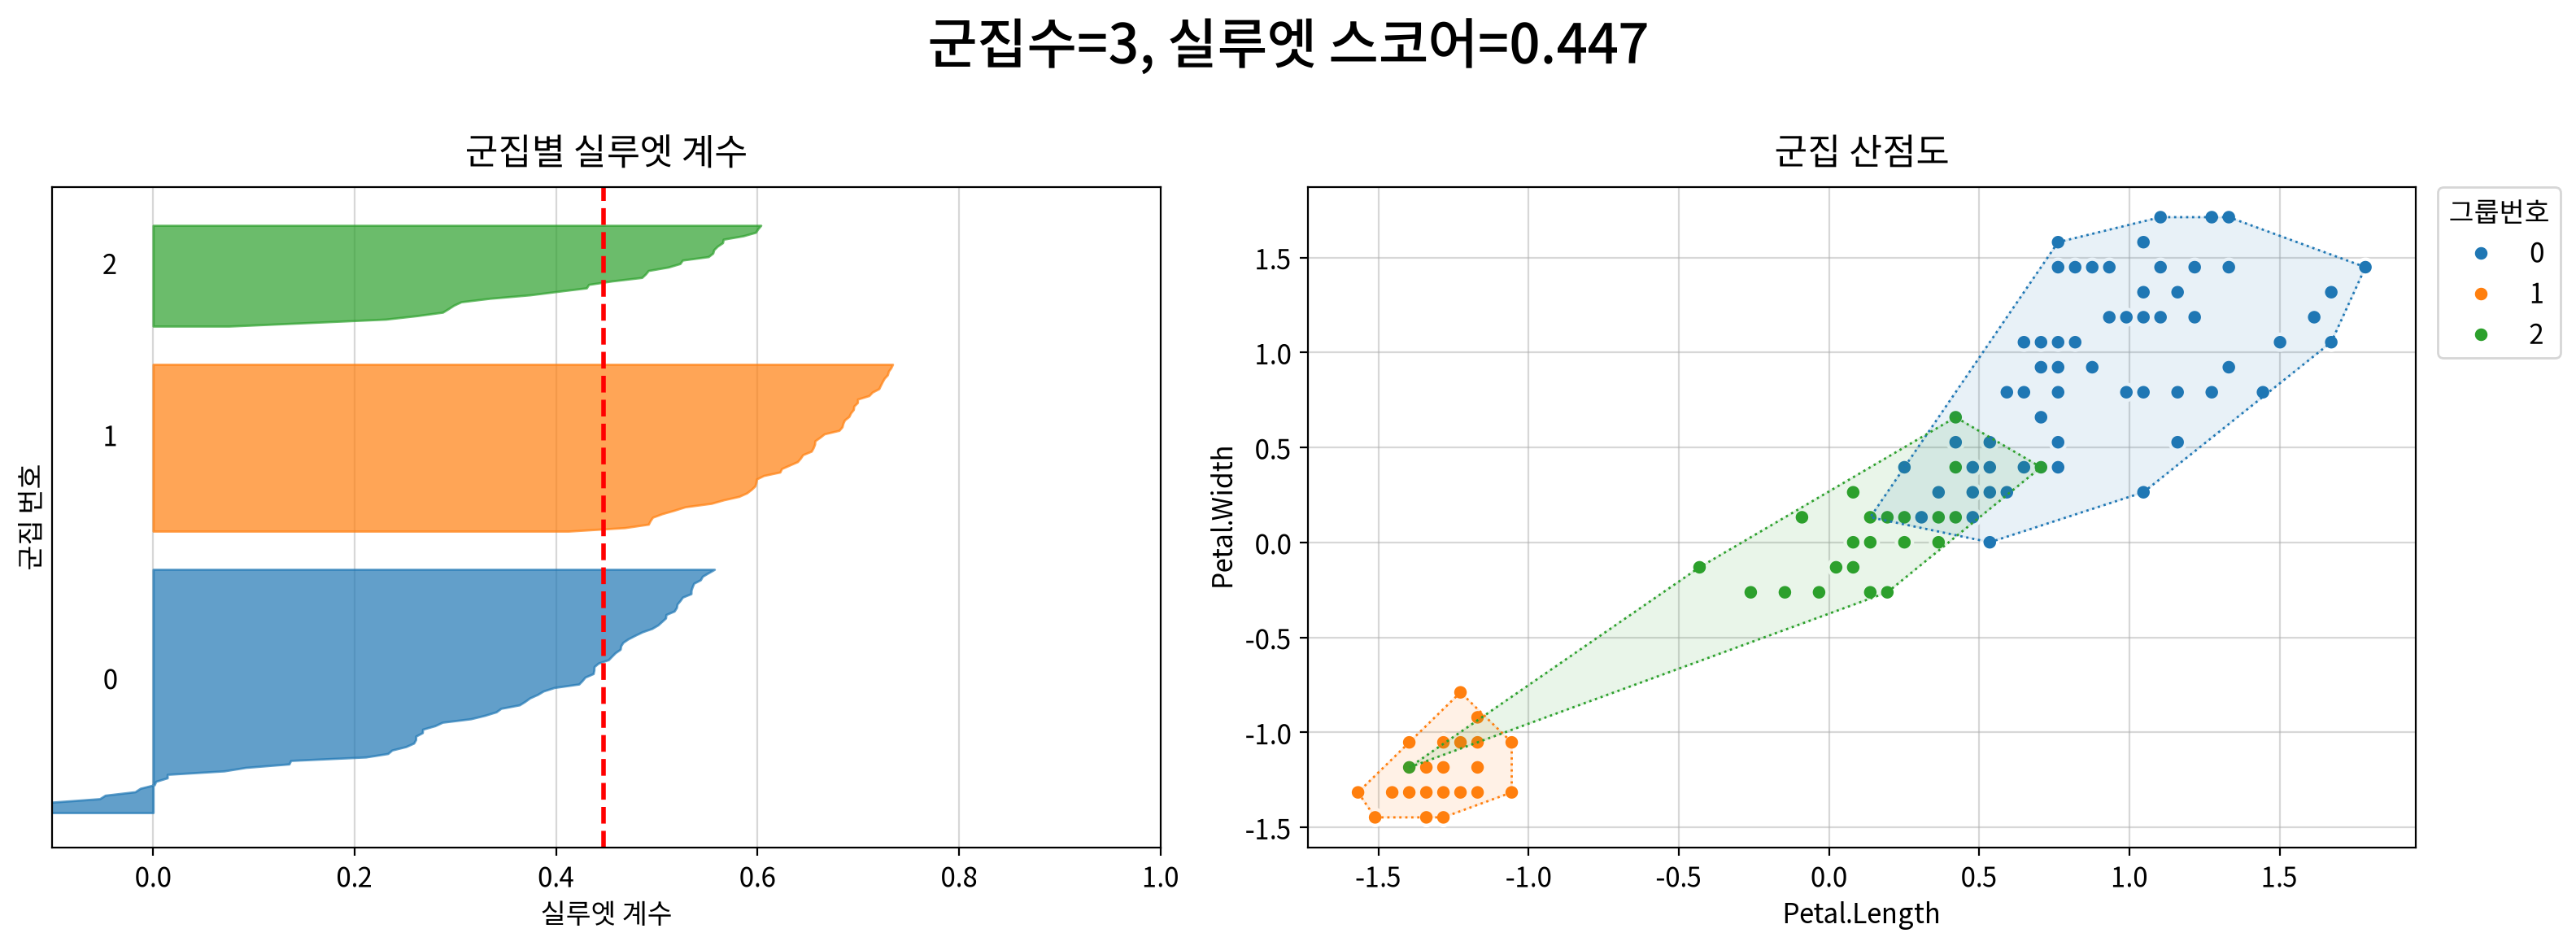

In [67]:
my_cluster.visualize_silhouette(estimator, cdf, 
                                x="Petal.Length", y="Petal.Width")

#### 💡 인사이트

- 맨 위에서 **두 개의 큰 덩어리**가 마지막에 합쳐진다 → 데이터가 크게 둘로 나뉜다는 뜻
  - 실루엣이 K = 2 를 가장 높게 준 이유가 바로 이것이다
- 오른쪽 덩어리는 중간 높이에서 다시 둘로 갈라진다 → 여기까지 보면 **3개 그룹**
- 그 아래는 짧은 거리에서 촘촘히 합쳐진다 → 더 잘게 나눌 이유가 없다

> 덴드로그램은 **"몇 개로 나눌까"** 를 눈으로 결정하게 해준다.
> 세로축에서 **가지가 가장 길게 뻗은 구간**을 가로로 자르면 된다.

### 4. 실제 품종과 비교해 보기

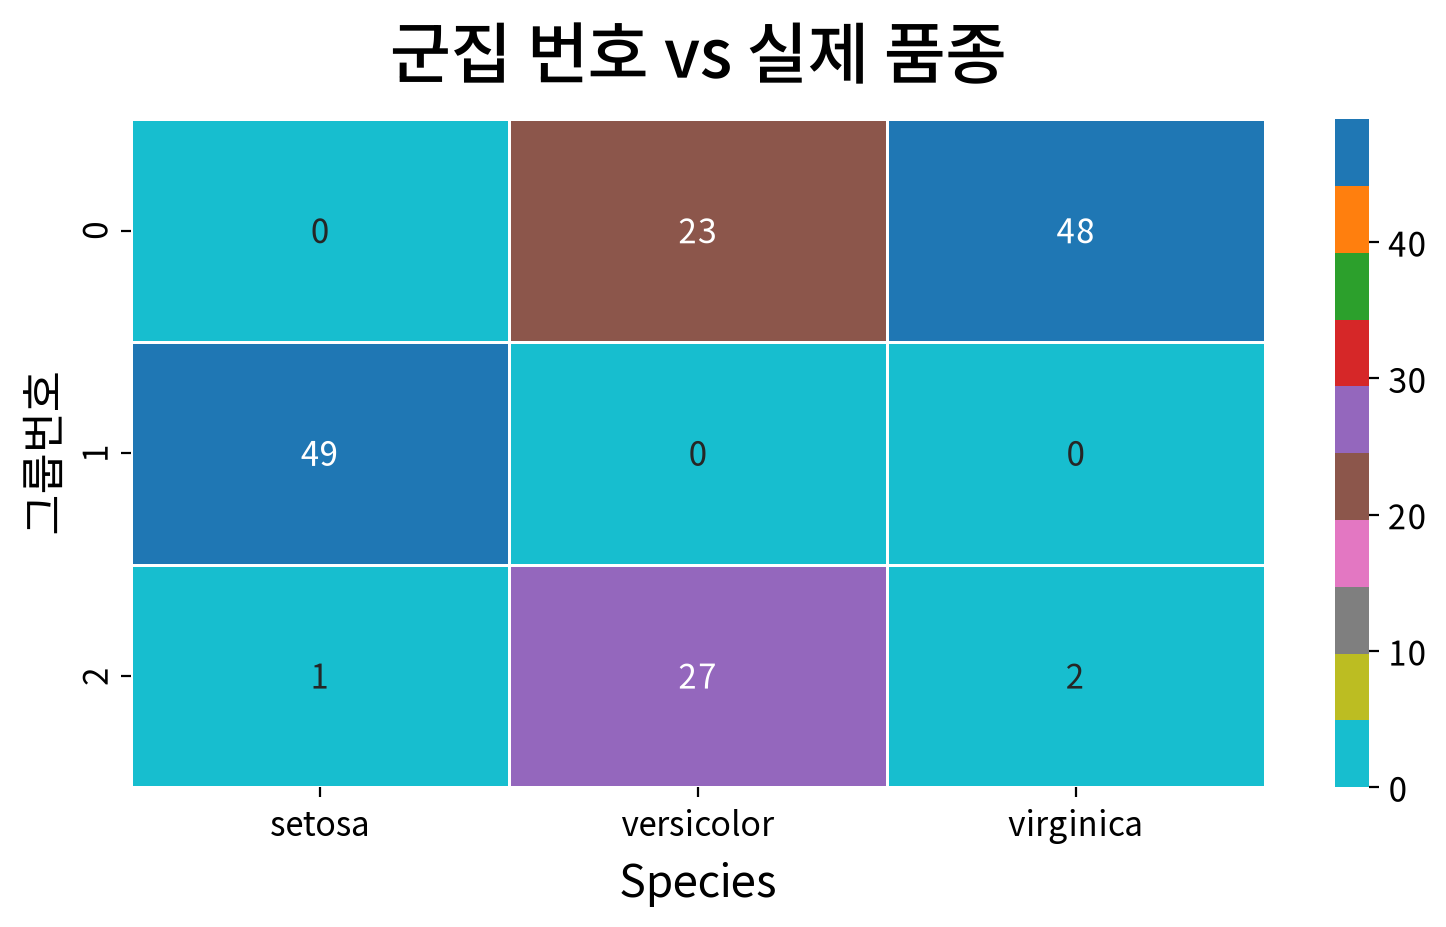

In [71]:
ct = crosstab(result_df["그룹번호"], origin["Species"])

# 교차표를 눈으로 바로 읽을 수 있도록 히트맵으로도 확인
my_plot.heatmap(data=ct, fmt="d", width=800, height=480, 
                palette="tab10_r", annot=True, 
                title="군집 번호 vs 실제 품종", 
                xlabel="실제 품종", ylabel="군집 번호")

#### 💡 인사이트

- ​군집 1 = setosa 49개로 거의 완벽히 일치 — 덴드로그램에서 먼저 갈라져 나온 덩어리
- ​versicolor 50개가 군집 0(23) 과 군집 2(27) 로 갈라졌다 → 두 품종이 실제로 비슷하게 생겼기 때문
- ​군집 크기는 71 · 49 · 30 으로 고르지 않다